In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return np.exp(-x) - x

In [3]:
print("input data")
xi = float(input("regula falsi xi: "))
xu = float(input("regula falsi xu: "))
x0 = float(input("secant x0(xi-1): "))
x1 = float(input("secant x1: "))
es = float(input("error toleransi: "))

# xi batas bawah
# xu batas atas
# ea approximate error
# es error toleransi
def regulafalsi(xi, xu, es):
    # inisialisasi variabel 
    ea = 100
    list_error = []
    list_xr = []
    list_x = []
    iter = 0

    # selama ea lebih besar dari es, lanjutkan iterasi
    while(ea > es):
        # tambah iterasi & tambahkan nilai iter ke list_x
        iter += 1 
        list_x.append(iter) 
        # tampilkan iterasi, xi, xu, f(xi), f(xu). batesin 4 angka belakang koma
        print(f"Iterasi ke {iter}")
        print(f"xi : {xi:.4f}, xu : {xu:.4f}")
        print(f"f(xi) : {f(xi):.4f}, f(xu) : {f(xu):.4f}")

        # rumus regulafalsi
        xr = xu - (f(xu) * (xi-xu))/(f(xi)-f(xu))
        print(f"xr : {xr:.4f}")
        print(f"f(xr) : {f(xr):.4f}")

        # hitung approximate error (ea) kalau udah iterasi 2
        if(iter > 1):
            ea = abs((xr - xr_old)/xr)*100 # rumus approximate error
            print(f"ea : {ea:.4f}")
            list_error.append(ea)

        # kalau f(xi) * f(xr) < 0, maka akar berada di antara xi dan xr, maka xu = xr
        if(f(xi)*f(xr) <0):
            xu = xr
        # kalau f(xi) * f(xr) > 0, maka akar berada di antara xr dan xu, maka xi = xr
        elif(f(xi)*f(xr) >0):
            xi = xr
        else:
            break

        # tambahkan xr ke akhir list_xr
        list_xr.append(xr)
        # simpan nilai xr sekarang ke xr_old
        xr_old = xr
        
    return list_error, list_xr, list_x
        

input data


In [4]:
def Secant(x0, x1, es):
    # inisialisasi awal
    ea = 100
    iterasi = 0
    nilai_ea = []
    nilai_xr = []
    nilai_x = []

    # loop selama ea > es
    while (ea > es):
        # iterasi bertambah
        iterasi += 1
        print(f"iterasi ke-{iterasi}")

        # hitung xr dengan rumus secant
        # x2 atau xr itu xi+1
        # x1 itu xi-1
        # x0 itu xi
        x2 = x0 - (f(x0)*(x0-x1))/(f(x0)-f(x1))

        # tambahkan iterasi ke list_x, dan xr ke list_xr
        nilai_x.append(iterasi)
        nilai_xr.append(x2)

        # tampilkan xi, xi-1, xi+1, f(xi), f(xi-1)
        print(f"xi \t= {x0:.4f}")           
        print(f"xi-1 \t= {x1:.4f}")
        print(f"xi+1 \t= {x2:.4f}")
        print(f"f(xi) \t= {f(x0):.4f}")
        print(f"f(xi-1) = {f(x1):.4f}")

        # hitung ea jika iterasi > 1
        if(iterasi > 1):
            ea = abs((x2-x0)/x2)*100
            nilai_ea.append(ea)
            
            print(f"ea \t= {ea:.4f}")

        x1 = x0 # xi-1 iterasi berikutnya = xi iterasi sebelumnya
        x0 = x2 # xi iterasi berikutnya = xi+1 iterasi sebelumnya
        
    return nilai_ea, nilai_xr, nilai_x

In [5]:
listError_RF, listAkar_RF, listX_RF = regulafalsi(xi, xu, es)

print("Akar Regula Falsi:", listAkar_RF)
print("Iterasi Regula Falsi", listX_RF)
print("Error Regula Falsi", listError_RF)

Iterasi ke 1
xi : 1.0000, xu : 2.0000
f(xi) : -0.6321, f(xu) : -1.8647
xr : 0.4871
f(xr) : 0.1272
Iterasi ke 2
xi : 1.0000, xu : 0.4871
f(xi) : -0.6321, f(xu) : 0.1272
xr : 0.5731
f(xr) : -0.0093
ea : 14.9953
Iterasi ke 3
xi : 0.5731, xu : 0.4871
f(xi) : -0.0093, f(xu) : 0.1272
xr : 0.5672
f(xr) : -0.0001
ea : 1.0307
Akar Regula Falsi: [0.48714165349848604, 0.5730763104310872, 0.5672301456031228]
Iterasi Regula Falsi [1, 2, 3]
Error Regula Falsi [14.995325294105813, 1.0306512926509421]


In [6]:
listError_SECANT, listAkar_SECANT, listX_SECANT = Secant(x0, x1, es)

print("Akar Secant:", listAkar_SECANT)
print("Iterasi Secant:", listX_SECANT)
print("Error Secant:", listError_SECANT)

iterasi ke-1
xi 	= 1.0000
xi-1 	= 2.0000
xi+1 	= 0.4871
f(xi) 	= -0.6321
f(xi-1) = -1.8647
iterasi ke-2
xi 	= 0.4871
xi-1 	= 1.0000
xi+1 	= 0.5731
f(xi) 	= 0.1272
f(xi-1) = -0.6321
ea 	= 14.9953
iterasi ke-3
xi 	= 0.5731
xi-1 	= 0.4871
xi+1 	= 0.5672
f(xi) 	= -0.0093
f(xi-1) = 0.1272
ea 	= 1.0307
Akar Secant: [0.4871416534984859, 0.5730763104310872, 0.5672301456031228]
Iterasi Secant: [1, 2, 3]
Error Secant: [14.995325294105832, 1.0306512926509421]


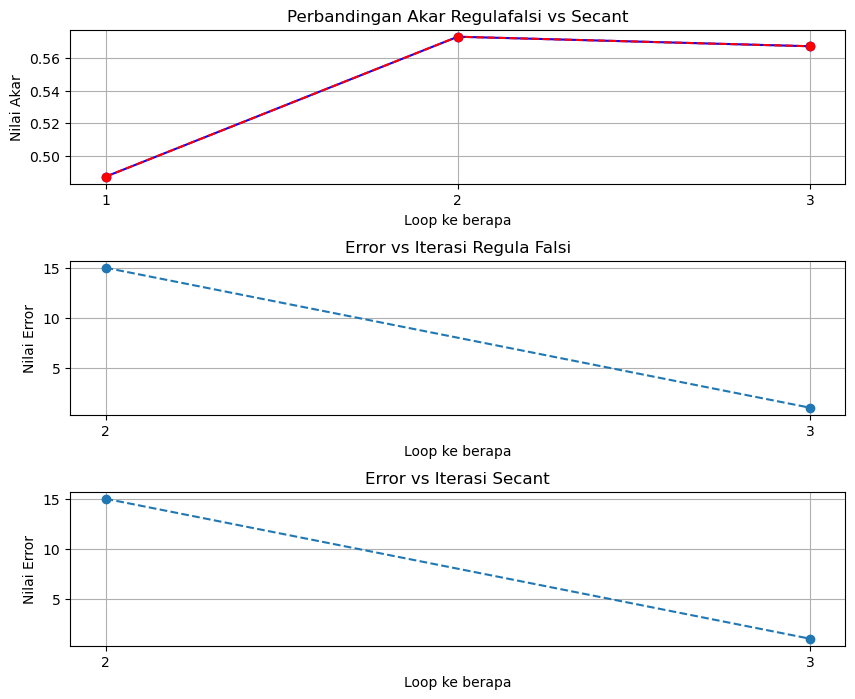

In [7]:
# visualisasi grafik
plt.figure(figsize=(10,8))

# subplot 1 akar vs iterasi
plt.subplot(311)
plt.title("Perbandingan Akar Regulafalsi vs Secant")
plt.plot(listX_RF, listAkar_RF, "bo-", label="regula falsi")
plt.plot(listX_SECANT, listAkar_SECANT, "r--o", label="secant")
plt.xlabel("Loop ke berapa")
plt.ylabel("Nilai Akar")
plt.xticks(range(1, max(len(listX_RF), len(listX_SECANT)) + 1))
plt.grid()

# subplot 2 error regulafalsi
plt.subplot(312)
plt.title("Error vs Iterasi Regula Falsi")
plt.plot(listX_RF[1:], listError_RF, "--o")
plt.xlabel("Loop ke berapa")
plt.ylabel("Nilai Error")
plt.xticks(listX_RF[1:])
plt.grid()

# subplot 3 error secant
plt.subplot(313)
plt.title("Error vs Iterasi Secant")
plt.plot(listX_SECANT[1:], listError_SECANT, "--o")
plt.xlabel("Loop ke berapa")
plt.ylabel("Nilai Error")
plt.xticks(listX_SECANT[1:])
plt.grid()

plt.subplots_adjust(hspace=0.5)
plt.savefig("RegulaFalsi vs Secant.png")
plt.show()